In [1]:
import pandas as pd
import numpy as np


In [7]:
directory = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\Project\\Starbucks\\directory.csv")
drink_expanded = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\Project\\Starbucks\\starbucks_drinkMenu_expanded.csv")

nutrition_drinks = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\Project\\Starbucks\\starbucks-menu-nutrition-drinks.csv")

nutrition_food = pd.read_csv(r"C:\\Users\\hp\\OneDrive\\Desktop\\Project\\Starbucks\\starbucks-menu-nutrition-food.csv",encoding="latin1")


In [8]:
print(directory.shape)

print(drink_expanded.shape)

print(nutrition_drinks.shape)

print(nutrition_food.shape)

(25600, 13)
(242, 18)
(177, 7)
(228, 1)


In [9]:
for name, df in {
    "directory": directory,
    "drink_expanded": drink_expanded,
    "nutrition_drinks": nutrition_drinks,
    "nutrition_food": nutrition_food
}.items():

    print("\n", name)

    print(df.isnull().sum())


 directory
Brand                0
Store Number         0
Store Name           0
Ownership Type       0
Street Address       2
City                15
State/Province       0
Country              0
Postcode          1522
Phone Number      6861
Timezone             0
Longitude            1
Latitude             1
dtype: int64

 drink_expanded
Beverage_category            0
Beverage                     0
Beverage_prep                0
Calories                     0
 Total Fat (g)               0
Trans Fat (g)                0
Saturated Fat (g)            0
 Sodium (mg)                 0
 Total Carbohydrates (g)     0
Cholesterol (mg)             0
 Dietary Fibre (g)           0
 Sugars (g)                  0
 Protein (g)                 0
Vitamin A (% DV)             0
Vitamin C (% DV)             0
 Calcium (% DV)              0
Iron (% DV)                  0
Caffeine (mg)                1
dtype: int64

 nutrition_drinks
Unnamed: 0    0
Calories      0
Fat (g)       0
Carb. (g)     0
Fiber

In [10]:
directory.drop_duplicates(
    inplace=True
)

In [11]:
text_cols = [
    "Brand",
    "Store Name",
    "Ownership Type",
    "City",
    "Country"
]

for col in text_cols:
    directory[col] = (
        directory[col]
        .astype(str)
        .str.strip()
    )

In [12]:
directory = directory.dropna(
    subset=[
        "Latitude",
        "Longitude"
    ]
)

In [13]:
drink_expanded.drop_duplicates(
    inplace=True
)

In [14]:
drink_expanded.columns = (
    drink_expanded.columns
    .str.strip()
    .str.replace(" ", "_")
)

In [15]:
for col in drink_expanded.columns:

    try:
        drink_expanded[col] = pd.to_numeric(
            drink_expanded[col]
        )
    except:
        pass

In [16]:
nutrition_drinks.drop_duplicates(
    inplace=True
)

In [17]:
nutrition_drinks.columns = (
    nutrition_drinks.columns
    .str.strip()
    .str.replace(" ", "_")
)

In [18]:
nutrition_drinks.fillna(
    0,
    inplace=True
)

,Unnamed:_0,Calories,Fat_(g),Carb._(g),Fiber_(g),Protein,Sodium
0,Cool Lime Starbucks Refreshers™ Beverage,45,0,11,0,0,10
1,Ombré Pink Drink,-,-,-,-,-,-
2,Pink Drink,-,-,-,-,-,-
3,Strawberry Acai Starbucks Refreshers™ Beverage,80,0,18,1,0,10
4,Very Berry Hibiscus Starbucks Refreshers™ Beve...,60,0,14,1,0,10
...,...,...,...,...,...,...,...
172,Chocolate Smoothie,320,5,53,8,20,170
173,Strawberry Smoothie,300,2,60,7,16,130
174,Ginger Ale,-,-,-,-,-,-
175,Lemon Ale,-,-,-,-,-,-


In [19]:
nutrition_food.drop_duplicates(
    inplace=True
)

In [20]:
nutrition_food.columns = (
    nutrition_food.columns
    .str.strip()
    .str.replace(" ", "_")
)

In [21]:
nutrition_food.fillna(
    0,
    inplace=True
)

,ÿþ
0,0.0


In [22]:
directory.to_csv(
    "directory_cleaned.csv",
    index=False
)

drink_expanded.to_csv(
    "drink_expanded_cleaned.csv",
    index=False
)

nutrition_drinks.to_csv(
    "nutrition_drinks_cleaned.csv",
    index=False
)

nutrition_food.to_csv(
    "nutrition_food_cleaned.csv",
    index=False
)

In [23]:
# First 5 rows
directory.head()
directory.tail()
print("Shape:", directory.shape)
print(directory.columns)
directory.info()
directory.describe(include='all')

Shape: (25599, 13)
Index(['Brand', 'Store Number', 'Store Name', 'Ownership Type',
       'Street Address', 'City', 'State/Province', 'Country', 'Postcode',
       'Phone Number', 'Timezone', 'Longitude', 'Latitude'],
      dtype='str')
<class 'pandas.DataFrame'>
Index: 25599 entries, 0 to 25599
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           25599 non-null  str    
 1   Store Number    25599 non-null  str    
 2   Store Name      25599 non-null  str    
 3   Ownership Type  25599 non-null  str    
 4   Street Address  25597 non-null  str    
 5   City            25584 non-null  str    
 6   State/Province  25599 non-null  str    
 7   Country         25599 non-null  str    
 8   Postcode        24077 non-null  str    
 9   Phone Number    18739 non-null  str    
 10  Timezone        25599 non-null  str    
 11  Longitude       25599 non-null  float64
 12  Latitude        25599 non-null  flo

,Brand,Store Number,Store Name,Ownership Type,Street Address,City,State/Province,Country,Postcode,Phone Number,Timezone,Longitude,Latitude
count,25599,25599,25599,25599,25597,25584,25599,25599,24077,18739,25599,25599.000000,25599.000000
unique,4,25599,25364,4,25353,5469,338,73,18887,18498,101,NaN,NaN
top,Starbucks,47370-257954,Starbucks,Company Owned,"Circular Building #6, Guard Post 8",上海市,CA,US,0,4.20235E+11,GMT-05:00 America/New_York,NaN,NaN
freq,25248,1,224,11932,11,542,2821,13608,101,26,4889,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-27.872234,34.793016
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.844046,13.342332
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-159.460000,-46.410000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-104.665000,31.240000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-79.350000,36.750000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.630000,41.570000


In [24]:
missing_values = directory.isnull().sum()

print(missing_values)


Brand                0
Store Number         0
Store Name           0
Ownership Type       0
Street Address       2
City                15
State/Province       0
Country              0
Postcode          1522
Phone Number      6860
Timezone             0
Longitude            0
Latitude             0
dtype: int64


In [25]:
missing_percent = (
    directory.isnull().sum() /
    len(directory)
) * 100

missing_percent.sort_values(
    ascending=False
)

Phone Number      26.797922
Postcode           5.945545
City               0.058596
Street Address     0.007813
Brand              0.000000
Ownership Type     0.000000
Store Name         0.000000
Store Number       0.000000
State/Province     0.000000
Country            0.000000
Timezone           0.000000
Longitude          0.000000
Latitude           0.000000
dtype: float64

In [26]:
directory.columns
if 'Phone Number' in directory.columns:
    directory.drop(
        'Phone Number',
        axis=1,
        inplace=True
    )

In [27]:
directory.columns

Index(['Brand', 'Store Number', 'Store Name', 'Ownership Type',
       'Street Address', 'City', 'State/Province', 'Country', 'Postcode',
       'Timezone', 'Longitude', 'Latitude'],
      dtype='str')

In [28]:
duplicate_count = directory.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [29]:
country_counts = (
    directory['Country']
    .value_counts()
)

print(country_counts)

Country
US    13608
CN     2734
CA     1468
JP     1237
KR      992
      ...  
TT        3
ZA        3
LU        2
MC        2
AD        1
Name: count, Length: 73, dtype: int64


In [30]:
city_counts = (
    directory['City']
    .value_counts()
)

print(city_counts)

City
上海市             542
Seoul           242
北京市             234
New York        232
London          216
               ... 
Rock Springs      1
Sheridian         1
Johannesburg      1
Menlyn            1
Midrand           1
Name: count, Length: 5469, dtype: int64


In [31]:
top_10_countries = (
    directory['Country']
    .value_counts()
    .head(10)
)

print(top_10_countries)

Country
US    13608
CN     2734
CA     1468
JP     1237
KR      992
GB      901
MX      579
TW      394
TR      326
PH      298
Name: count, dtype: int64


In [32]:
top_10_cities = (
    directory['City']
    .value_counts()
    .head(10)
)

print(top_10_cities)

City
上海市            542
Seoul          242
北京市            234
New York       232
London         216
Toronto        192
Mexico City    180
Chicago        180
Las Vegas      156
Seattle        156
Name: count, dtype: int64


In [33]:
ownership_analysis = (
    directory['Ownership Type']
    .value_counts()
)

print(ownership_analysis)

Ownership Type
Company Owned    11932
Licensed          9375
Joint Venture     3975
Franchise          317
Name: count, dtype: int64


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

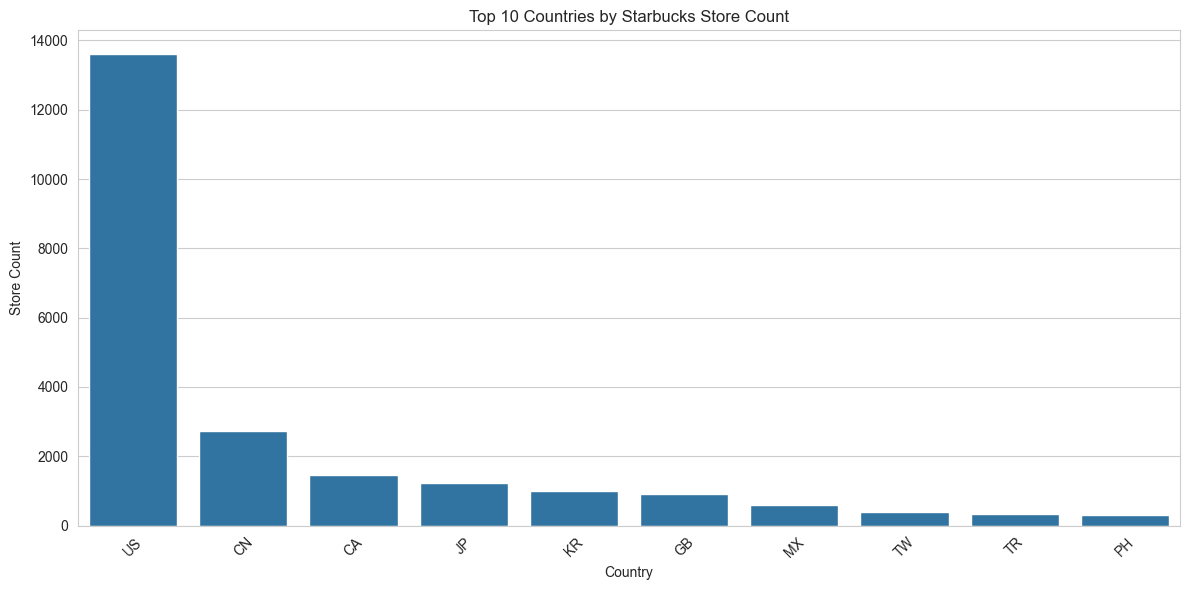

Chart saved successfully!


In [48]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Path where images will be saved
image_path = r"C:\Users\hp\OneDrive\Desktop\Project\Starbucks"

# Create chart
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_countries.index,
    y=top_10_countries.values
)

plt.title("Top 10 Countries by Starbucks Store Count")
plt.xlabel("Country")
plt.ylabel("Store Count")
plt.xticks(rotation=45)

plt.tight_layout()

# Save chart
plt.savefig(
    os.path.join(
        image_path,
        "Top 10 Countries.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully!")

C:\Users\hp\AppData\Local\Temp\ipykernel_9232\3746359286.py:21: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_9232\3746359286.py:21: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_9232\3746359286.py:21: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_9232\3746359286.py:21: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAPH-5317}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_9232\3746359286.py:21: UserWarning: Glyph 20140 (\N{CJK UNIFIED IDEOGRAPH-4EAC}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_9232\3746359286.py:24: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) Ar

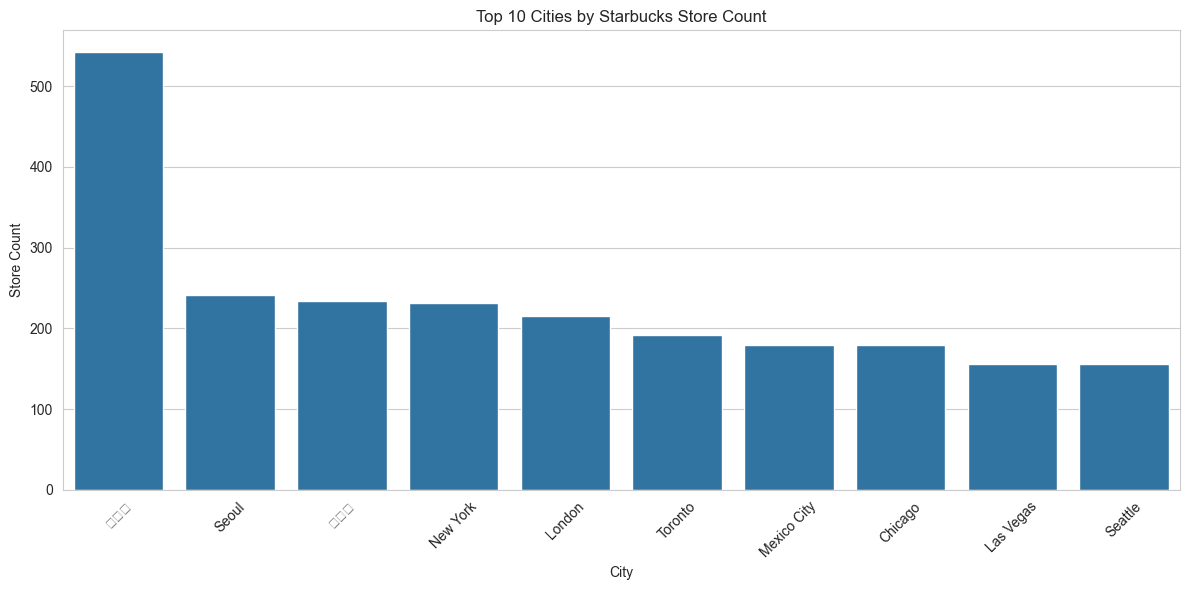

Chart saved successfully!


In [50]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Path where images will be saved
image_path = r"C:\Users\hp\OneDrive\Desktop\Project\Starbucks"

# Create chart
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_cities.index,
    y=top_10_cities.values
)

plt.title("Top 10 Cities by Starbucks Store Count")
plt.xlabel("City")
plt.ylabel("Store Count")
plt.xticks(rotation=45)

plt.tight_layout()

# Save chart
plt.savefig(
    os.path.join(
        image_path,
        "Top 10 Cities.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully!")
plt.show()

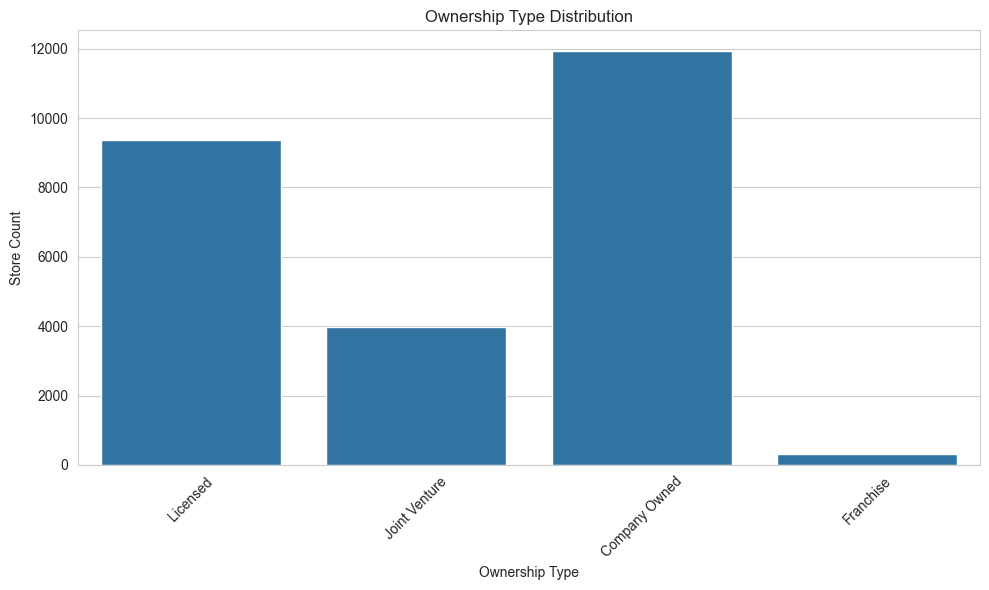

Chart saved successfully!


In [51]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Folder where images will be saved
image_path = r"C:\Users\hp\OneDrive\Desktop\Project\Starbucks"

plt.figure(figsize=(10,6))

sns.countplot(
    data=directory,
    x='Ownership Type'
)

plt.title("Ownership Type Distribution")
plt.xlabel("Ownership Type")
plt.ylabel("Store Count")

plt.xticks(rotation=45)

plt.tight_layout()

# Save chart
plt.savefig(
    os.path.join(
        image_path,
        "03_Ownership_Type_Distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully!")

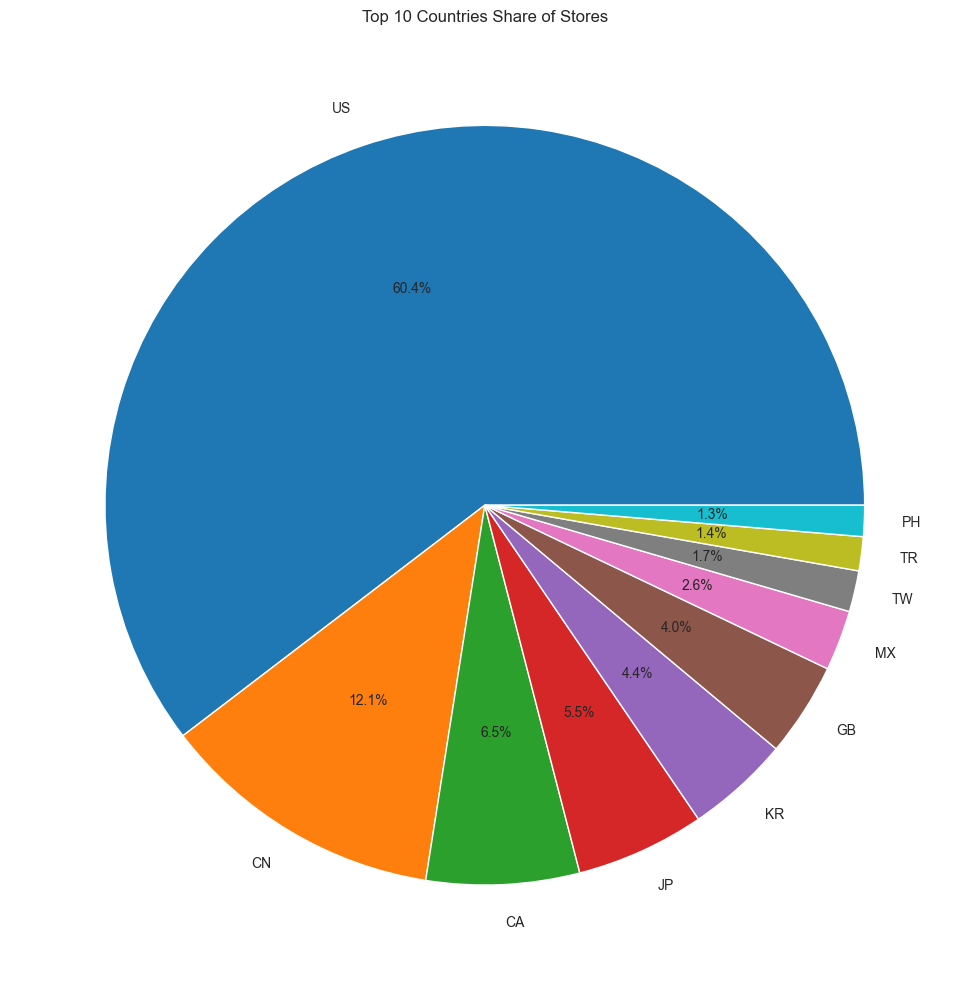

Chart saved successfully!


In [52]:
import os
import matplotlib.pyplot as plt

# Folder where images will be saved
image_path = r"C:\Users\hp\OneDrive\Desktop\Project\Starbucks"

plt.figure(figsize=(10,10))

top_10_countries.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Top 10 Countries Share of Stores")

plt.ylabel("")

plt.tight_layout()

# Save chart
plt.savefig(
    os.path.join(
        image_path,
        "04_Country_Share_PieChart.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully!")

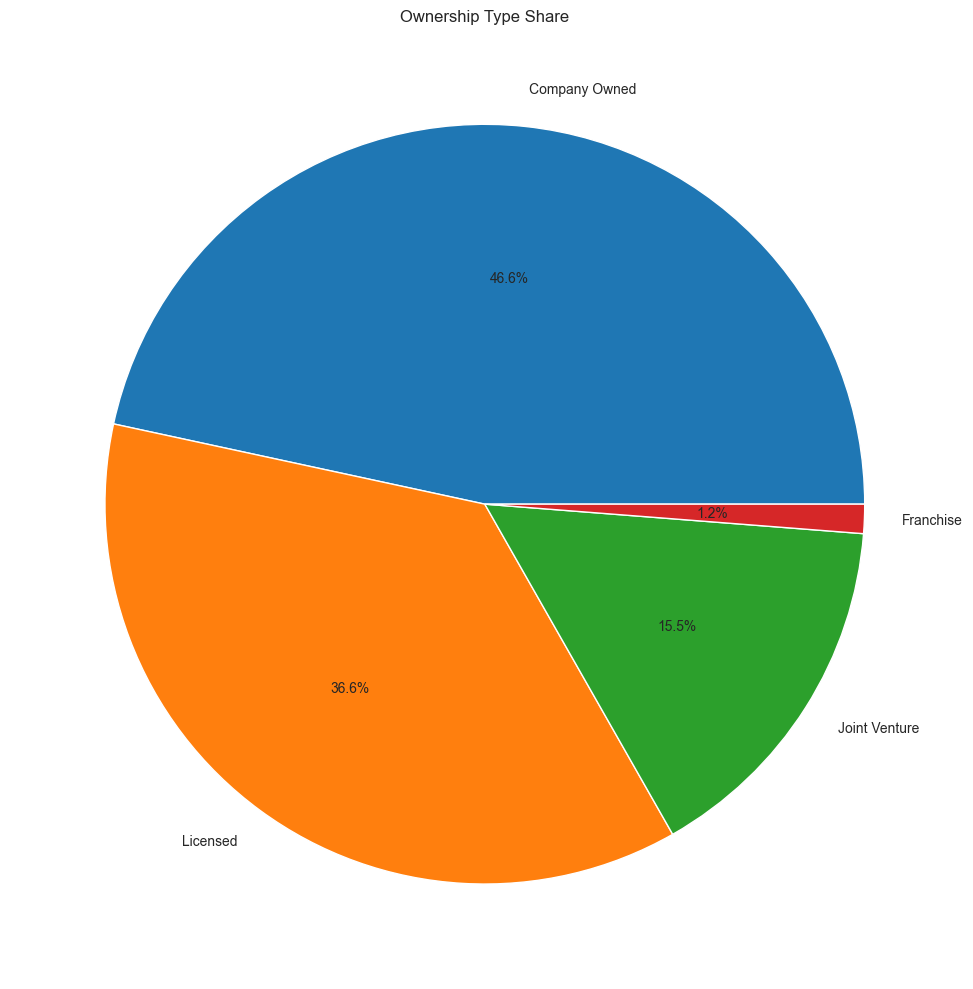

Chart saved successfully!


In [53]:
import os
import matplotlib.pyplot as plt

# Folder where images will be saved
image_path = r"C:\Users\hp\OneDrive\Desktop\Project\Starbucks"

plt.figure(figsize=(10,10))

ownership_analysis.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Ownership Type Share")

plt.ylabel("")

plt.tight_layout()

# Save chart
plt.savefig(
    os.path.join(
        image_path,
        "05_Ownership_Share_PieChart.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully!")

In [40]:
print(
    "Total Countries:",
    directory['Country'].nunique()
)

Total Countries: 73


In [41]:
print(
    "Total Cities:",
    directory['City'].nunique()
)

Total Cities: 5469


In [42]:
print(
    "Ownership Types:",
    directory['Ownership Type'].nunique()
)

Ownership Types: 4


In [43]:
directory.to_csv(
    "directory_cleaned.csv",
    index=False
)

print(
    "directory_cleaned.csv saved successfully!"
)

directory_cleaned.csv saved successfully!


In [44]:
country_counts.to_csv(
    "country_counts.csv"
)

city_counts.to_csv(
    "city_counts.csv"
)

ownership_analysis.to_csv(
    "ownership_analysis.csv"
)

In [1]:
import pandas as pd
from sqlalchemy import create_engine

# PostgreSQL connection
username = "postgres"
password = "2802"
host = "localhost"
port = "5432"
database = "Starbucks Global Store Intelligence Analysis"

# CSV file path
csv_file = r"C:\\Users\\hp\\directory_cleaned.csv"

# Read CSV
df = pd.read_csv(csv_file)

print("Rows:", len(df))
print("Columns:", len(df.columns))

# Connect PostgreSQL
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

# Upload table
df.to_sql(
    "starbucks_stores",
    engine,
    if_exists="replace",  # replace existing table
    index=False
)

print("Data imported successfully!")

Rows: 25599
Columns: 12
Data imported successfully!
